# Concours MTH3302

In [52]:
using CSV
using DataFrames
using Gadfly
using HypothesisTests
using LinearAlgebra
using Statistics
using StatsPlots
using Combinatorics
using StatsModels
using CategoricalArrays
using StatsBase
using Random
using GaussianMixtures

include("Jeremie_Utils.jl")

bayesian_prediction (generic function with 1 method)

In [3]:
train = CSV.read("train.csv", DataFrame, decimal=',')
test = CSV.read("test.csv", DataFrame, decimal=',');

# Partie 1
## Régressions linéaires simples

In [4]:
y = train.consommation
n = length(y)

396

In [5]:
function compute_residuals(model, y)
    ŷ = StatsModels.predict(model)
    res = (y - ŷ) / std(ŷ)

    return res
end

function plot_explanatory_variable(model, data, xlabel)
    predictions = StatsModels.predict(model)

    Gadfly.plot(
        x = data.x, 
        y = data.y,
        layer(
            x = data.x,
            y = predictions,
            Geom.line,
            Theme(default_color="red"),
        ),
        Geom.point,
        Guide.xlabel(xlabel), 
        Guide.ylabel("Consommation d'essence (L/100km)", orientation=:vertical),
    )
end

function qqplot_test(model, data)
    errors = compute_residuals(model, data.y)

    qqnorm(errors, qqline = :R)
end

function shapiro_wilk_test(model, data)
    errors = compute_residuals(model, data.y)
    p = pvalue(ShapiroWilkTest(errors))

    if p > 0.05
        println("$p > 0.05 -> On accepte l'hypothèse que les données proviennent d'une distribution normale")
    else 
        println("$p ≤ 0.05 -> On rejette l'hypothèse que les données proviennent d'une distribution normale")
    end
end

function residuals_vs_fitted_values_plot_test(model, data)
    errors = compute_residuals(model, data.y)
    fitted_values = fitted(model)

    Gadfly.plot(
        layer(x=fitted_values, y=errors, Geom.point),
        Guide.xlabel("Valeurs prédites"),
        Guide.ylabel("Résidus"),
    )
end

function residuals_vs_observation_order_plot_test(model, data)
    errors = compute_residuals(model, data.y)

    Gadfly.plot(
        layer(x=1:length(errors), y=errors, Geom.point),
        Guide.xlabel("Index"),
        Guide.ylabel("Résidus"),
    )
end

function get_data_set(seed, features, preprocess::Function = data -> nothing)
    Random.seed!(seed)
    data = CSV.read("train.csv", DataFrame, decimal=',')

    preprocess(data)

    train_id = sample(1:nrow(data), round(Int, .8*nrow(data)), ordered=true, replace=false)
    valid_id = setdiff(1:nrow(data), train_id)

    train = data[train_id,:]
    train = remove_outliers(train, features, :consommation)
    valid = data[valid_id,:]

    return train, valid
end

function align_categorical_features(train, valid, features)
    data = vcat(train, valid)

    categorical_features = filter(x -> eltype(data[:, x]) <: AbstractString || eltype(data[:, x]) <: CategoricalValue, features)
    for feature in categorical_features
        train_values = unique(train[!, feature])
        valid_values = unique(valid[!, feature])

        train_indices_to_remove = findall(x -> !(x in valid_values), train[!, feature])
        train = train[setdiff(1:nrow(train), train_indices_to_remove), :]

        valid_indices_to_remove = findall(x -> !(x in train_values), valid[!, feature])
        valid = valid[setdiff(1:nrow(valid), valid_indices_to_remove), :]
    end

    return train, valid
end

function update_features(data, features) 
    return vec(reduce(vcat, [
        filter(name -> startswith(name, string(feature)), names(data))
        for feature in features
    ]))
end

update_features (generic function with 1 method)

## 1.1 Analyse de la variable _nombre_cylindres_

In [ ]:
x = string.(train.nombre_cylindres)
data = DataFrame(y = train.consommation, x = x)
model = create_model(data, [:x])

**Vérification de l'hypothèse de linéarité**

In [ ]:
plot_explanatory_variable(model, data, "Nombre de cylindres")

**Vérification de l'hypothèse de normalité des erreurs**

In [ ]:
qqplot_test(model, data)

In [ ]:
shapiro_wilk_test(model, data)

**Vérification de l'hypothèse d'homosédasticité des erreurs**

In [ ]:
residuals_vs_fitted_values_plot_test(model, data)

**Vérification de l'hypothèse d'indépendance des erreurs**

In [ ]:
residuals_vs_observation_order_plot_test(model, data)

In [ ]:
r2(model)

## 1.2 Analyse de la variable _type_

In [186]:
data = DataFrame(y = train.consommation, x = train.type)
model = linear_model(data, [:x])

StatsModels.TableRegressionModel{LinearModel{GLM.LmResp{Vector{Float64}}, GLM.DensePredChol{Float64, CholeskyPivoted{Float64, Matrix{Float64}, Vector{Int64}}}}, Matrix{Float64}}

y ~ 1 + x

Coefficients:
───────────────────────────────────────────────────────────────────────────────────────
                              Coef.  Std. Error      t  Pr(>|t|)   Lower 95%  Upper 95%
───────────────────────────────────────────────────────────────────────────────────────
(Intercept)                9.86155     0.167288  58.95    <1e-99   9.53262    10.1905
x: VUS_standard            3.09082     0.408216   7.57    <1e-12   2.28816     3.89348
x: break_moyen             1.33893     1.75453    0.76    0.4459  -2.11094     4.7888
x: break_petit            -1.396       0.639754  -2.18    0.0297  -2.65392    -0.138074
x: camionnette_petit       1.03346     0.79879    1.29    0.1965  -0.53717     2.60409
x: camionnette_standard    3.97433     1.24627    3.19    0.0015   1.52384     6.42482
x: monospac

**Vérification de l'hypothèse de linéarité**

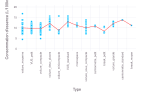

In [187]:
plot_explanatory_variable(model, data, "Type")

**Vérification de l'hypothèse de normalité des erreurs**

In [ ]:
qqplot_test(model, data)

In [ ]:
shapiro_wilk_test(model, data)

**Vérification de l'hypothèse d'homosédasticité des erreurs**

In [ ]:
residuals_vs_fitted_values_plot_test(model, data)

**Vérification de l'hypothèse d'indépendance des erreurs**

In [ ]:
residuals_vs_observation_order_plot_test(model, data)

In [ ]:
r2(model)

## 1.3 Analyse de la variable _cylindree_

In [ ]:
data = DataFrame(y = train.consommation, x = log.(train.cylindree))
model = create_model(data, [:x])

# data = DataFrame(y = train.consommation, x = train.cylindree, x² = train.cylindree .^ 2)
# model = create_model(data, [:x, :x²])

**Vérification de l'hypothèse de linéarité**

In [ ]:
plot_explanatory_variable(model, data, "Cylindrée")

**Vérification de l'hypothèse de normalité des erreurs**

In [ ]:
qqplot_test(model, data)

In [ ]:
shapiro_wilk_test(model, data)

**Vérification de l'hypothèse d'homosédasticité des erreurs**

In [ ]:
residuals_vs_fitted_values_plot_test(model, data)

**Vérification de l'hypothèse d'indépendance des erreurs**

In [ ]:
residuals_vs_observation_order_plot_test(model, data)

In [ ]:
r2(model)

## 1.4 Analyse de la variable _transmission_

In [ ]:
x = train.transmission
data = DataFrame(y = train.consommation, x = x)
data = remove_outliers(data)
model = create_model(data, [:x])

**Vérification de l'hypothèse de linéarité**

In [ ]:
plot_explanatory_variable(model, data, "Transmission")

**Vérification de l'hypothèse de normalité des erreurs**

In [ ]:
qqplot_test(model, data)

In [ ]:
shapiro_wilk_test(model, data)

**Vérification de l'hypothèse d'homosédasticité des erreurs**

In [ ]:
residuals_vs_fitted_values_plot_test(model, data)

**Vérification de l'hypothèse d'indépendance des erreurs**

In [ ]:
residuals_vs_observation_order_plot_test(model, data)

In [ ]:
r2(model)

## 1.5 Analyse de la variable _boite_

In [ ]:
data = DataFrame(y = train.consommation, x = train.boite)
data = remove_outliers(data)
model = create_model(data, [:x])

**Vérification de l'hypothèse de linéarité**

In [ ]:
plot_explanatory_variable(model, data, "Cylindrée")

**Vérification de l'hypothèse de normalité des erreurs**

In [ ]:
qqplot_test(model, data)

In [ ]:
shapiro_wilk_test(model, data)

**Vérification de l'hypothèse d'homosédasticité des erreurs**

In [ ]:
residuals_vs_fitted_values_plot_test(model, data)

**Vérification de l'hypothèse d'indépendance des erreurs**

In [ ]:
residuals_vs_observation_order_plot_test(model, data)

In [ ]:
r2(model)

## 1.6 Analyse de la variable _annee_

In [ ]:
data = DataFrame(y = train.consommation, x = train.annee)
coerce!(data, :x => Multiclass)
model = create_model(data, [:x])

In [ ]:
plot_explanatory_variable(model, data, "Année")

In [ ]:
r2(model)

# Partie 2 
## Régression linéaire multiple

In [82]:
seed = 8542

features = [:type, :transmission, :boite, :annee, :nombre_cylindres, :cylindree]
nominal_features = [:type, :transmission, :boite, :annee]
ordinal_features = []
continuous_features = [:cylindree, :nombre_cylindres]

2-element Vector{Symbol}:
 :cylindree
 :nombre_cylindres

In [83]:
train, valid = get_data_set(seed, features)
model = linear_model(train, features, :consommation)

ŷ = float.(StatsModels.predict(model, valid))
y_valid = valid[:, :consommation]

rms(ŷ, y_valid)

0.9262729470233285

In [ ]:
train, valid = get_data_set(seed, features)

model = create_model(train, features, :consommation)

ŷ = float.(StatsModels.predict(model, valid))
y_valid = valid[:, :consommation]

rms(ŷ, y_valid)

In [ ]:
train, valid = get_data_set(seed, features, data -> begin
    coerce!(data, :annee => Multiclass)
end)

model = create_model(train, features, :consommation)

ŷ = float.(StatsModels.predict(model, valid))
y_valid = valid[:, :consommation]

rms(ŷ, y_valid)

In [ ]:
train, valid = get_data_set(seed, features)
train, valid = align_categorical_features(train, valid, features)

y_train = train[!, :consommation]
X_train = train[!, features]
X_train = encode(X_train, categorical_features, continuous_features, ordinal_features)

X_valid = valid[!, features]
X_valid = encode(X_valid, categorical_features, continuous_features, ordinal_features)

mach = linear_regression(X_train, y_train)

ŷ = MLJ.predict(mach, X_valid)
y_valid = valid[:, :consommation]

rms(ŷ, y_valid)

In [ ]:
train, valid = get_data_set(seed, features)
train, valid = align_categorical_features(train, valid, features)

y_train = train[!, :consommation]
X_train = train[!, features]
X_train = encode(X_train, nominal_features, continuous_features, ordinal_features)

X_valid = valid[!, features]
X_valid = encode(X_valid, nominal_features, continuous_features, ordinal_features)

mach = ridge_regression_cv(X_train, y_train)

ŷ = MLJ.predict(mach, X_valid)
y_valid = valid[:, :consommation]

rms(ŷ, y_valid)

0.9125865906672691

In [ ]:
train, valid = get_data_set(seed, features)
train, valid = align_categorical_features(train, valid, features)

y_train = train[!, :consommation]
X_train = train[!, features]
X_train = encode(X_train, categorical_features, vcat(continuous_features, ordinal_features), [])

X_valid = valid[!, features]
X_valid = encode(X_valid, categorical_features, vcat(continuous_features, ordinal_features), [])

mach = lasso_regression_cv(X_train, y_train)

ŷ = MLJ.predict(mach, X_valid)
y_valid = valid[:, :consommation]

rms(ŷ, y_valid)

In [ ]:
include("Jeremie_Utils.jl")
train, valid = get_data_set(seed, features)
train, valid = align_categorical_features(train, valid, features)

y_train = train[!, :consommation]
X_train = train[!, features]
X_train = encode(X_train, categorical_features, vcat(continuous_features, ordinal_features), [])

X_valid = valid[!, features]
X_valid = encode(X_valid, categorical_features, vcat(continuous_features, ordinal_features), [])

mach = elastic_net_regression_cv(X_train, y_train)

ŷ = MLJ.predict(mach, X_valid)
y_valid = valid[:, :consommation]

rms(ŷ, y_valid)

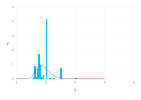

In [239]:
# https://www.kaggle.com/datasets/aishwaryamuthukumar/cars-dataset-audi-bmw-ford-hyundai-skoda-vw
data = CSV.read("cars_dataset_1.csv", DataFrame, decimal=',')
data = filter(x -> x.year >= 2014 && parse(Float64, x.engineSize) > 1, data)
data.engine_size = String.(data[!, :engineSize])
data.engine_size = parse.(Float64, data[!, :engine_size])
# data.engine_size = log.(data[!, :engine_size])

k = 2
gmm = GMM(k, data.engine_size)
μ = gmm.μ[:,]
Σ = gmm.Σ[:,]
ω = gmm.w[:,]

# dist_cylindree = MixtureModel(Normal[Normal(μ[i], Σ[i]) for i in 1:k], ω)
dist_cylindree = fit(LogNormal, data.engine_size)

Gadfly.plot(
    layer(x->pdf(dist_cylindree, x), 0, 6, Theme(default_color=colorant"red")),
    layer(x=data.engine_size, Geom.histogram(density=true)),
)

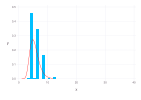

In [233]:
# https://www.kaggle.com/datasets/CooperUnion/cardataset/data
data = CSV.read("cars_dataset_2.csv", DataFrame, decimal=',')
data.engine_cylinders = data[!, "Engine Cylinders"]
data = filter(x -> x.Year >= 2014, data)
data = filter(x -> !ismissing(x.engine_cylinders) && x.engine_cylinders > 1, data)
data.engine_cylinders = map(x -> float(x), data.engine_cylinders)
# data.engine_cylinders = log.(data.engine_cylinders)

dist_nombre_cylindres = fit(LogNormal, data.engine_cylinders)

Gadfly.plot(
    layer(x->pdf(dist_nombre_cylindres, x), 1, 12, Theme(default_color=colorant"red")),
    layer(x=data.engine_cylinders, Geom.histogram(bincount=30, density=true)),
)

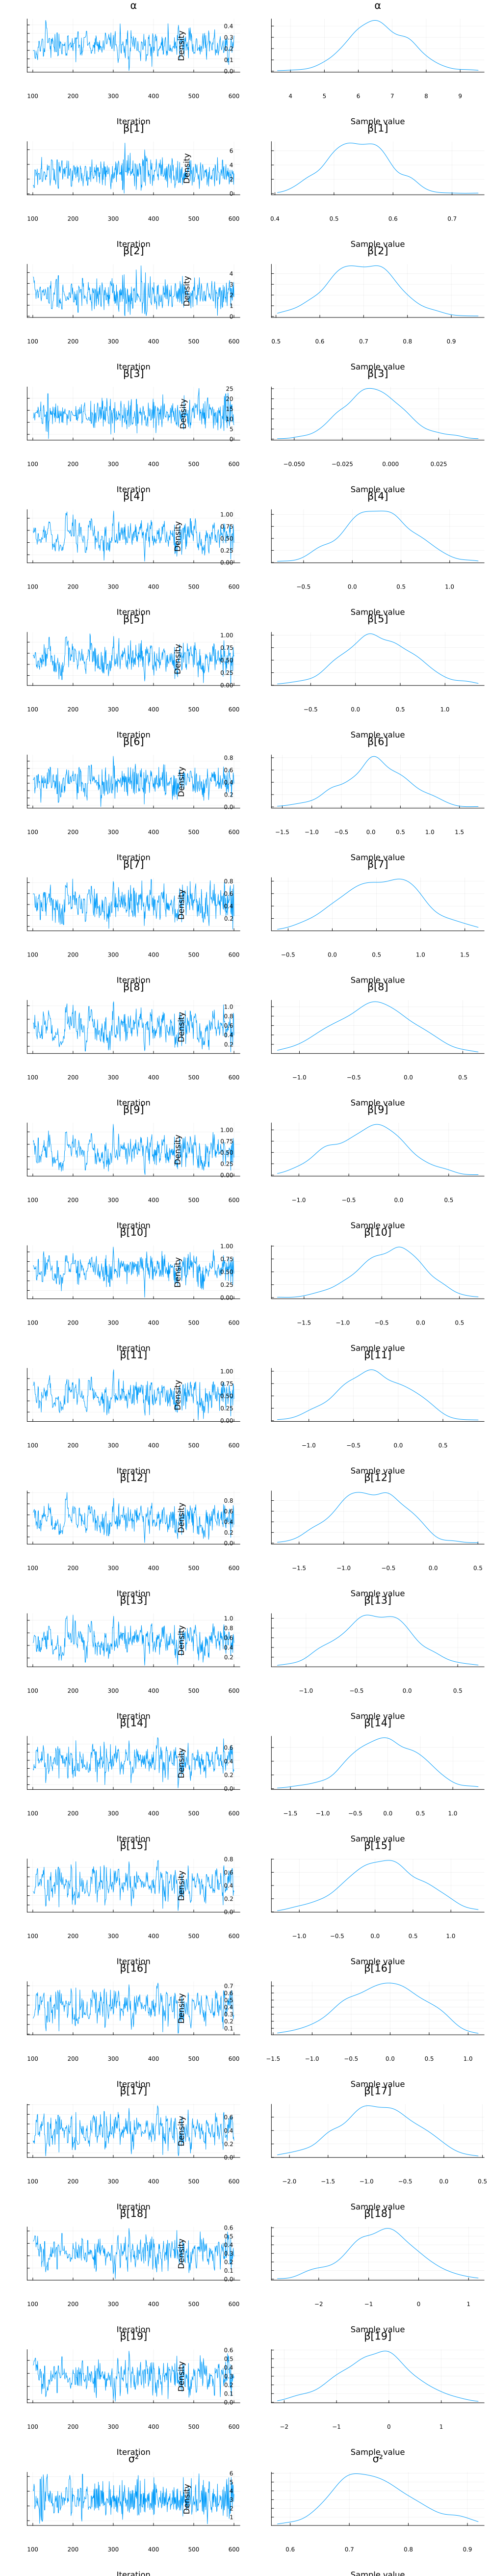

In [244]:
include("Jeremie_Utils.jl")
features = [:nombre_cylindres, :cylindree, :annee, :type, :transmission, :boite]
categorical_features = [:type, :transmission, :boite]
ordinal_features = []
continuous_features = []

train, valid = get_data_set(seed, features)
train, valid = align_categorical_features(train, valid, features)

train.annee = train.annee .- minimum(train.annee)
# train.cylindree = log.(train.cylindree)
# train.nombre_cylindres = log.(train.nombre_cylindres)
valid.annee = valid.annee .- minimum(valid.annee)
# valid.cylindree = log.(valid.cylindree)
# valid.nombre_cylindres = log.(valid.nombre_cylindres)

y_train = train[!, :consommation]
X_train = train[!, features]
X_train = encode(X_train, categorical_features, continuous_features, ordinal_features)

y_valid = valid[!, :consommation]
X_valid = valid[!, features]
X_valid = encode(X_valid, categorical_features, continuous_features, ordinal_features)

model = bayesian_regression(
    X_train, 
    y_train, 
    Dict(
        "cylindree" => dist_cylindree,
        "nombre_cylindres" => dist_nombre_cylindres
    )
)
chain = sample(model, NUTS(), 500, discard_initial = 100)

StatsPlots.plot(chain)
# ŷ = bayesian_prediction(chain, X_valid)
# rms(ŷ, y_valid)

### Régression linéaire pour soumission

In [ ]:
test = CSV.read("test.csv", DataFrame, decimal=',');
train, valid = get_data_set(seed, features)
train = vcat(train, valid)

X_train = train[!, features]
y_train = train[!, :consommation]

# X_train, test = align_categorical_features(X_train, test, features)

X_train = encode(X_train, categorical_features, continuous_features, ordinal_features)
test = encode(test, categorical_features, continuous_features, ordinal_features)

mach = linear_regression(X_train, y_train)

ŷ = MLJ.predict(mach, test)

df_pred = DataFrame(id=1:size(test, 1), consommation=ŷ)
CSV.write("benchmark.csv", df_pred)

### Régression Ridge pour soumission

In [ ]:
test = CSV.read("test.csv", DataFrame, decimal=',');

features = [:nombre_cylindres, :cylindree, :annee, :type, :transmission, :boite]
categorical_features = [:type, :transmission, :boite]
ordinal_features = []
continuous_features = []

train, valid = get_data_set(seed, features)
train = vcat(train, valid)

train.annee = train.annee ./ maximum(train.annee)
# train.cylindree = log.(train.cylindree)
# train.nombre_cylindres = log.(train.nombre_cylindres)
test.annee = test.annee ./ maximum(test.annee)
# test.cylindree = log.(test.cylindree)
# test.nombre_cylindres = log.(test.nombre_cylindres)

X_train = train[!, features]
y_train = train[!, :consommation]

X_train = encode(X_train, categorical_features, continuous_features, ordinal_features)
test = encode(test, categorical_features, continuous_features, ordinal_features)

mach = lasso_regression_cv(X_train, y_train)

ŷ = MLJ.predict(mach, test)

df_pred = DataFrame(id=1:size(test, 1), consommation=ŷ)
CSV.write("benchmark.csv", df_pred)

"benchmark.csv"

### Régression bayésienne pour soumission

In [240]:
include("Jeremie_Utils.jl")

features = [:nombre_cylindres, :cylindree, :annee, :type, :transmission, :boite]
categorical_features = [:type, :transmission, :boite]
ordinal_features = []
continuous_features = []

test = CSV.read("test.csv", DataFrame, decimal=',');
train, valid = get_data_set(seed, features)
train = vcat(train, valid)

train.annee = train.annee .- minimum(train.annee)
# train.cylindree = log.(train.cylindree)
# train.nombre_cylindres = log.(train.nombre_cylindres)
test.annee = test.annee .- minimum(test.annee)
# test.cylindree = log.(test.cylindree)
# test.nombre_cylindres = log.(test.nombre_cylindres)

X_train = train[!, features]
y_train = train[!, :consommation]
X_test = test[!, features]

X_train = encode(X_train, categorical_features, continuous_features, ordinal_features)
X_test = encode(X_test, categorical_features, continuous_features, ordinal_features)

model = bayesian_regression(
    X_train, 
    y_train, 
    Dict(
        "cylindree" => dist_cylindree,
        "nombre_cylindres" => dist_nombre_cylindres
    )
)
chain = sample(model, NUTS(), 1000)

ŷ = bayesian_prediction(chain, X_test)

df_pred = DataFrame(id=1:size(test, 1), consommation=ŷ)
CSV.write("benchmark.csv", df_pred)

"benchmark.csv"

In [243]:
best_pred = CSV.read("benchmark.csv", DataFrame, decimal='.')
current_pred = CSV.read("current_best.csv", DataFrame, decimal='.')

rms(best_pred.consommation, current_pred.consommation)

0.09928193581452431